## 1. Setup & pcap parser


In [2]:
import struct
import hashlib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 60)

CR_PATH = "cr.pcap"
CS_PATH = "cs.pcap"

In [3]:
def read_pcap(path):
    records = []
    with open(path, "rb") as f:
        gh = f.read(24)
        if len(gh) < 24:
            raise ValueError(f"{path}: truncated global header")
        magic = struct.unpack("<I", gh[:4])[0]
        if magic == 0xa1b2c3d4:
            endian, ts_div = "<", 1e6
        elif magic == 0xa1b23c4d:
            endian, ts_div = "<", 1e9
        elif magic == 0xd4c3b2a1:
            endian, ts_div = ">", 1e6
        elif magic == 0x4d3cb2a1:
            endian, ts_div = ">", 1e9
        else:
            raise ValueError(f"{path}: unrecognized pcap magic {magic:#x}")
        idx = 0
        while True:
            rec_header = f.read(16)
            if len(rec_header) < 16:
                break
            ts_sec, ts_frac, incl_len, _orig_len = struct.unpack(endian + "IIII", rec_header)
            frame = f.read(incl_len)
            if len(frame) < incl_len:
                break
            records.append((idx, ts_sec + ts_frac / ts_div, frame))
            idx += 1
    return records

## 2. Protocol classifier

In [4]:
_WELLKNOWN_TCP_PORTS = {53: "DNS", 80: "HTTP", 443: "HTTPS/TLS", 139: "SMB", 445: "SMB"}
_WELLKNOWN_UDP_PORTS = {
    53: "DNS", 67: "DHCP", 68: "DHCP", 443: "QUIC",
    137: "NBNS", 138: "NetBIOS", 1900: "SSDP",
    5353: "mDNS", 123: "NTP", 5355: "LLMNR", 3478: "STUN",
}

def classify_protocol(frame: bytes) -> str:
    if len(frame) < 14:
        return "Malformed"
    eth_type = struct.unpack("!H", frame[12:14])[0]
    off = 14
    if eth_type == 0x8100:  # 802.1Q VLAN tag
        if len(frame) < 18:
            return "Malformed"
        eth_type = struct.unpack("!H", frame[16:18])[0]
        off = 18

    if eth_type == 0x0806:
        return "ARP"
    if eth_type == 0x86DD:
        return "IPv6"
    if eth_type != 0x0800:
        return f"EthType-0x{eth_type:04x}"

    if len(frame) < off + 20:
        return "IPv4 (short)"
    ihl = (frame[off] & 0x0F) * 4
    proto = frame[off + 9]
    l4_off = off + ihl

    if proto == 1:
        return "ICMP"
    if proto == 2:
        return "IGMP"
    if proto in (6, 17):
        base = "TCP" if proto == 6 else "UDP"
        if len(frame) >= l4_off + 4:
            sport, dport = struct.unpack("!HH", frame[l4_off:l4_off + 4])
            port_map = _WELLKNOWN_TCP_PORTS if proto == 6 else _WELLKNOWN_UDP_PORTS
            app = port_map.get(sport) or port_map.get(dport)
            if app:
                return f"{base}/{app}"
        return base
    return f"IPv4-proto-{proto}"

def dest_mac_kind(frame: bytes) -> str:
    """broadcast / multicast / unicast, based on the destination MAC."""
    dst = frame[0:6]
    if dst == b"\xff\xff\xff\xff\xff\xff":
        return "broadcast"
    if dst and (dst[0] & 0x01):
        return "multicast"
    return "unicast"

## Load both captures into DataFrames


In [5]:
cr_records = read_pcap(CR_PATH)
cs_records = read_pcap(CS_PATH)
print(f"cr.pcap: {len(cr_records):,} packets")
print(f"cs.pcap: {len(cs_records):,} packets")

cr.pcap: 55,177 packets
cs.pcap: 106,523 packets


In [6]:
def to_dataframe(records, capture_name):
    rows = []
    for idx, ts, frame in records:
        rows.append({
            "capture": capture_name,
            "idx": idx,
            "ts": ts,
            "length": len(frame),
            "protocol": classify_protocol(frame),
            "dst_kind": dest_mac_kind(frame),
            "frame_hash": hashlib.sha1(frame).hexdigest(),
        })
    df = pd.DataFrame(rows)
    df.sort_values("ts", inplace=True, kind="mergesort")
    df.reset_index(drop=True, inplace=True)
    return df

df_cr = to_dataframe(cr_records, "cr")
df_cs = to_dataframe(cs_records, "cs")
df_cr.head()

,capture,idx,ts,length,protocol,dst_kind,frame_hash
0,cr,0,1.779710e+09,54,TCP/HTTPS/TLS,unicast,5eeb29c69109819172b7157bc5d39fc837609543
1,cr,1,1.779710e+09,55,TCP/HTTPS/TLS,unicast,f4540a705c5d8fe932e25e2ee813c7327b6c01fd
2,cr,2,1.779710e+09,66,TCP/HTTPS/TLS,unicast,665543c91762e68759d550c8fcb3c07c8850aca4
3,cr,3,1.779710e+09,95,UDP/DNS,unicast,afb7d228e6757352443f577c2c8cfdf489324bd8
4,cr,4,1.779710e+09,95,UDP/DNS,unicast,66b310548992424a3676985e45b7481228f9543c


## Identical-packet detection



In [7]:
common_hashes = set(df_cr["frame_hash"]) & set(df_cs["frame_hash"])

df_cr["observed_both"] = df_cr["frame_hash"].isin(common_hashes)
df_cs["observed_both"] = df_cs["frame_hash"].isin(common_hashes)

print(f"Unique identical frame contents seen by BOTH captures : {len(common_hashes):,}")
print(f"cr.pcap packets that are also present in cs.pcap      : {df_cr['observed_both'].sum():,} / {len(df_cr):,}")
print(f"cs.pcap packets that are also present in cr.pcap      : {df_cs['observed_both'].sum():,} / {len(df_cs):,}")

Unique identical frame contents seen by BOTH captures : 3,357
cr.pcap packets that are also present in cs.pcap      : 4,534 / 55,177
cs.pcap packets that are also present in cr.pcap      : 4,530 / 106,523


In [8]:
dst_kind_summary = (
    df_cr.groupby(["dst_kind", "observed_both"]).size()
    .unstack(fill_value=0)
    .rename(columns={False: "only_in_cr", True: "also_in_cs"})
)
dst_kind_summary

observed_both,only_in_cr,also_in_cs
dst_kind,,
broadcast,15,2569
multicast,294,1965
unicast,50334,0


## Per-protocol comparison (exploratory table + chart)


In [9]:
proto_compare = pd.DataFrame({
    "cr_total":  df_cr.groupby("protocol").size(),
    "cr_common": df_cr[df_cr.observed_both].groupby("protocol").size(),
    "cs_total":  df_cs.groupby("protocol").size(),
    "cs_common": df_cs[df_cs.observed_both].groupby("protocol").size(),
}).fillna(0).astype(int)

proto_compare["common_unique_frames"] = (
    df_cr[df_cr.observed_both].groupby("protocol")["frame_hash"].nunique()
).reindex(proto_compare.index).fillna(0).astype(int)

proto_compare = proto_compare.sort_values("common_unique_frames", ascending=False)
proto_compare

,cr_total,cr_common,cs_total,cs_common,common_unique_frames
protocol,,,,,
UDP,1745,1736,10641,1736,1736
UDP/mDNS,632,620,629,620,620
UDP/SSDP,820,578,979,578,578
IPv6,721,718,941,718,280
UDP/DHCP,57,54,57,54,54
UDP/NBNS,43,43,43,43,43
ARP,982,772,962,768,33
UDP/NetBIOS,11,6,11,6,6
IGMP,32,5,310,5,5


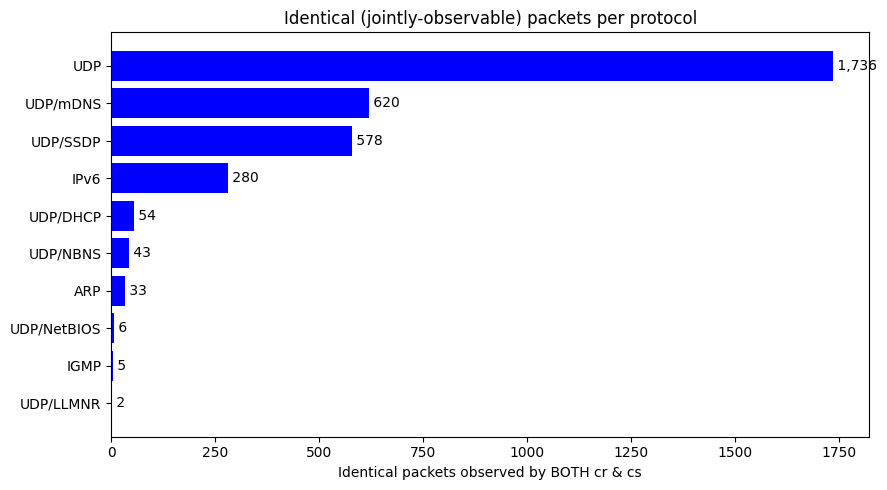

In [70]:
plot_df = proto_compare[proto_compare["common_unique_frames"] > 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df.index[::-1], plot_df["common_unique_frames"][::-1], color="blue")
ax.set_xlabel("Identical packets observed by BOTH cr & cs")
ax.set_title("Identical (jointly-observable) packets per protocol")
for i, v in enumerate(plot_df["common_unique_frames"][::-1]):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout()
plt.show()

## First observable shared packet as Anchor based on Intra-Connection Delay (ICD)

`ICD(packet) = (arrival_time(packet) - arrival_time(anchor)) * 1000`  → milliseconds, so the anchor itself is `0 ms`, and each following shared packet shows its delay since the anchor (e.g. `0ms, 32ms, 56ms, 70ms, ...`).

Two independent toggles below:
- `FORCE_ANCHOR_PROTOCOL` — which protocol's first shared packet defines `t = 0` (e.g. `"ARP"`).
- `RESTRICT_ICD_TO_ANCHOR_PROTOCOL` — if `True`, the ICD series itself only walks through packets of that *same* protocol (e.g. ARP-to-ARP ICD only). If `False`, ICD is computed across **all** jointly-observed protocols, just anchored at that first packet's time.


In [11]:
FORCE_ANCHOR_PROTOCOL = "ARP"
RESTRICT_ICD_TO_ANCHOR_PROTOCOL = True

candidates = df_cr[df_cr.observed_both].copy()
if FORCE_ANCHOR_PROTOCOL is not None:
    candidates = candidates[candidates["protocol"] == FORCE_ANCHOR_PROTOCOL]
    if candidates.empty:
        raise ValueError(f"No jointly-observed packets found for protocol={FORCE_ANCHOR_PROTOCOL!r}")

candidates = candidates.sort_values("ts")
anchor_row = candidates.iloc[0]
anchor_hash = anchor_row["frame_hash"]
anchor_protocol = anchor_row["protocol"]

anchor_ts_cr = df_cr.loc[df_cr["frame_hash"] == anchor_hash, "ts"].min()
anchor_ts_cs = df_cs.loc[df_cs["frame_hash"] == anchor_hash, "ts"].min()

print(f"Anchor (t=0) protocol : {anchor_protocol}")
print(f"Anchor frame hash     : {anchor_hash}")
print(f"Anchor time in cr.pcap: {anchor_ts_cr}")
print(f"Anchor time in cs.pcap: {anchor_ts_cs}")

Anchor (t=0) protocol : ARP
Anchor frame hash     : d89c25ed526c2736fbe1c1815bcc76183a8e6089
Anchor time in cr.pcap: 1779710264.730167
Anchor time in cs.pcap: 1779710264.517788


In [52]:
def build_icd_table(df, anchor_ts, capture_name, protocol_filter=None):
    shared = df[df.observed_both].copy()
    if protocol_filter is not None:
        shared = shared[shared["protocol"] == protocol_filter]
    shared = shared.sort_values("ts")
    shared = shared[shared["ts"] >= anchor_ts].reset_index(drop=True)
    shared["icd_ms"] = ((shared["ts"] - anchor_ts) * 10).round(0).astype(int)
    shared["capture"] = capture_name
    return shared[["capture", "idx", "ts", "protocol", "length", "frame_hash", "icd_ms"]]

_proto_filter = anchor_protocol if RESTRICT_ICD_TO_ANCHOR_PROTOCOL else None
icd_cr = build_icd_table(df_cr, anchor_ts_cr, "cr", protocol_filter=_proto_filter)
icd_cs = build_icd_table(df_cs, anchor_ts_cs, "cs", protocol_filter=_proto_filter)

print(f"ICD sequence observed in cr.pcap (ms since anchor){' \u2014 ' + anchor_protocol + ' only' if _proto_filter else ''}:")
display(icd_cr.head(1000))

ICD sequence observed in cr.pcap (ms since anchor) — ARP only:


,capture,idx,ts,protocol,length,frame_hash,icd_ms
0,cr,55,1.779710e+09,ARP,42,d89c25ed526c2736fbe1c1815bcc76183a8e6089,0
1,cr,60,1.779710e+09,ARP,42,d89c25ed526c2736fbe1c1815bcc76183a8e6089,10
2,cr,69,1.779710e+09,ARP,42,d89c25ed526c2736fbe1c1815bcc76183a8e6089,19
3,cr,76,1.779710e+09,ARP,42,80d702552d46ece72b81e4d93dedb6ddc9c2a70f,36
4,cr,82,1.779710e+09,ARP,42,80d702552d46ece72b81e4d93dedb6ddc9c2a70f,46
...,...,...,...,...,...,...,...
767,cr,55097,1.779714e+09,ARP,42,612e6a441ce60d90de730de95bc9c447e1899ed6,35627
768,cr,55107,1.779714e+09,ARP,42,612e6a441ce60d90de730de95bc9c447e1899ed6,35636
769,cr,55111,1.779714e+09,ARP,42,612e6a441ce60d90de730de95bc9c447e1899ed6,35646
770,cr,55119,1.779714e+09,ARP,42,612e6a441ce60d90de730de95bc9c447e1899ed6,35663


In [53]:
print("ICD sequence observed in cs.pcap (ms since anchor):")
icd_cs.head(1000)

ICD sequence observed in cs.pcap (ms since anchor):


,capture,idx,ts,protocol,length,frame_hash,icd_ms
0,cs,161,1.779710e+09,ARP,42,d89c25ed526c2736fbe1c1815bcc76183a8e6089,0
1,cs,169,1.779710e+09,ARP,42,d89c25ed526c2736fbe1c1815bcc76183a8e6089,10
2,cs,178,1.779710e+09,ARP,42,d89c25ed526c2736fbe1c1815bcc76183a8e6089,19
3,cs,200,1.779710e+09,ARP,42,80d702552d46ece72b81e4d93dedb6ddc9c2a70f,36
4,cs,210,1.779710e+09,ARP,42,80d702552d46ece72b81e4d93dedb6ddc9c2a70f,46
...,...,...,...,...,...,...,...
763,cs,106464,1.779714e+09,ARP,42,612e6a441ce60d90de730de95bc9c447e1899ed6,35610
764,cs,106490,1.779714e+09,ARP,42,612e6a441ce60d90de730de95bc9c447e1899ed6,35627
765,cs,106499,1.779714e+09,ARP,42,612e6a441ce60d90de730de95bc9c447e1899ed6,35636
766,cs,106505,1.779714e+09,ARP,42,612e6a441ce60d90de730de95bc9c447e1899ed6,35647


### ICD as a compact list (matches the requested `0ms, 32ms, 56ms, 70ms ...` style)


In [54]:
icd_list_cr = icd_cr["icd_ms"].round(1).tolist()
icd_list_cs = icd_cs["icd_ms"].round(1).tolist()

print("cr ICD (ms):", icd_list_cr[:15], "...")
print("cs ICD (ms):", icd_list_cs[:15], "...")

cr ICD (ms): [0, 10, 19, 36, 46, 56, 212, 222, 231, 364, 422, 426, 514, 524, 534] ...
cs ICD (ms): [0, 10, 19, 36, 46, 56, 212, 222, 232, 364, 422, 426, 514, 524, 534] ...


### 9. DNS Packets


In [58]:
DNS_PROTO = "UDP/mDNS"

dns_candidates = df_cr[df_cr.observed_both & (df_cr["protocol"] == DNS_PROTO)].copy()

if dns_candidates.empty:
    print(f"no identical found {DNS_PROTO}.")

else:
    dns_candidates = dns_candidates.sort_values("ts")
    dns_anchor_row = dns_candidates.iloc[0]
    dns_anchor_hash = dns_anchor_row["frame_hash"]

    dns_ts_cr = df_cr.loc[df_cr["frame_hash"] == dns_anchor_hash, "ts"].min()
    dns_ts_cs = df_cs.loc[df_cs["frame_hash"] == dns_anchor_hash, "ts"].min()

    icd_dns_cr = build_icd_table(df_cr, dns_ts_cr, "cr", protocol_filter=DNS_PROTO)
    icd_dns_cs = build_icd_table(df_cs, dns_ts_cs, "cs", protocol_filter=DNS_PROTO)

    print(f"Anchor {DNS_PROTO} (Hash: {dns_anchor_hash})")
    print(f"amount {DNS_PROTO} cr: {len(icd_dns_cr)}")
    print(f"amount {DNS_PROTO} cs: {len(icd_dns_cs)}")

    display(icd_dns_cr)
    display(icd_dns_cs)

    print("cr:", icd_dns_cr["icd_ms"].tolist()[:15])
    print("cs:", icd_dns_cs["icd_ms"].tolist()[:15])

Anchor UDP/mDNS (Hash: 99ba927efeb4a0d6ec00a1f1d0429963c5276c4f)
amount UDP/mDNS cr: 620
amount UDP/mDNS cs: 620


,capture,idx,ts,protocol,length,frame_hash,icd_ms
0,cr,56,1.779710e+09,UDP/mDNS,119,99ba927efeb4a0d6ec00a1f1d0429963c5276c4f,0
1,cr,80,1.779710e+09,UDP/mDNS,119,f2d2f075cda4ffed55f1fa066e331b0ddc011f34,43
2,cr,236,1.779710e+09,UDP/mDNS,119,261b375cb964a461d822650103515779b49bf489,201
3,cr,297,1.779710e+09,UDP/mDNS,119,3ccb1a17fa907aa346a2a49a281dc0f1e342476d,244
4,cr,589,1.779710e+09,UDP/mDNS,119,b7e6ee8b1f7621462c0991952b967d6b82737c91,400
...,...,...,...,...,...,...,...
615,cr,54819,1.779714e+09,UDP/mDNS,139,13e30a4dab283d7c2ad698b68016ef52a2f06bac,35313
616,cr,54944,1.779714e+09,UDP/mDNS,100,ad67d1723659b09a94ce31c3a3f2be8ec65bb90d,35458
617,cr,54992,1.779714e+09,UDP/mDNS,139,d9f59c1eff9dded3e12d986832c6bb27fb4d5010,35467
618,cr,55024,1.779714e+09,UDP/mDNS,139,ce0a254fd1506865e7a03501a44153200a53da24,35498


,capture,idx,ts,protocol,length,frame_hash,icd_ms
0,cs,162,1.779710e+09,UDP/mDNS,119,99ba927efeb4a0d6ec00a1f1d0429963c5276c4f,0
1,cs,208,1.779710e+09,UDP/mDNS,119,f2d2f075cda4ffed55f1fa066e331b0ddc011f34,43
2,cs,715,1.779710e+09,UDP/mDNS,119,261b375cb964a461d822650103515779b49bf489,201
3,cs,834,1.779710e+09,UDP/mDNS,119,3ccb1a17fa907aa346a2a49a281dc0f1e342476d,244
4,cs,1119,1.779710e+09,UDP/mDNS,119,b7e6ee8b1f7621462c0991952b967d6b82737c91,400
...,...,...,...,...,...,...,...
615,cs,105823,1.779714e+09,UDP/mDNS,139,13e30a4dab283d7c2ad698b68016ef52a2f06bac,35313
616,cs,106233,1.779714e+09,UDP/mDNS,100,ad67d1723659b09a94ce31c3a3f2be8ec65bb90d,35458
617,cs,106237,1.779714e+09,UDP/mDNS,139,d9f59c1eff9dded3e12d986832c6bb27fb4d5010,35467
618,cs,106284,1.779714e+09,UDP/mDNS,139,ce0a254fd1506865e7a03501a44153200a53da24,35498


cr: [0, 43, 201, 244, 400, 600, 801, 833, 833, 833, 843, 853, 1053, 1201, 1253]
cs: [0, 43, 201, 244, 400, 600, 801, 833, 833, 833, 843, 853, 1053, 1201, 1253]


Total : 620
Identical ICD : 541
similarity: 87.26%


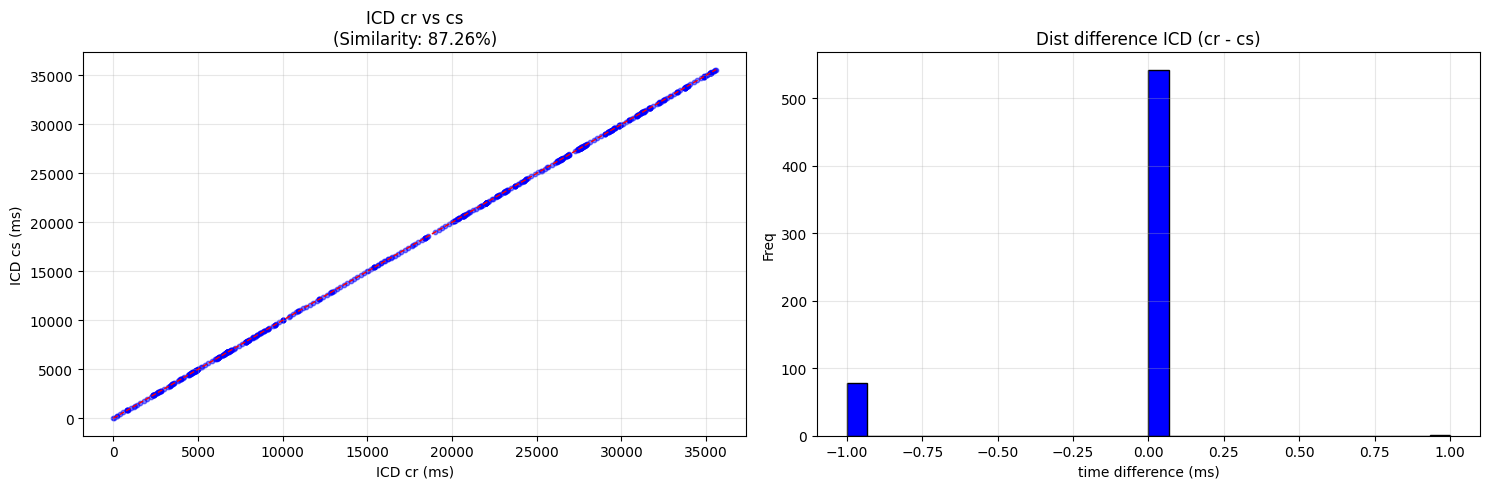

In [72]:
comparison_df = pd.merge(
    icd_dns_cr[['icd_ms']].rename(columns={'icd_ms': 'icd_cr'}),
    icd_dns_cs[['icd_ms']].rename(columns={'icd_ms': 'icd_cs'}),
    left_index=True,
    right_index=True
)

comparison_df['is_match'] = comparison_df['icd_cr'] == comparison_df['icd_cs']
match_count = comparison_df['is_match'].sum()
total_count = len(comparison_df)
similarity_pct = (match_count / total_count) * 100

print(f"Total : {total_count}")
print(f"Identical ICD : {match_count}")
print(f"similarity: {similarity_pct:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1
ax1.scatter(comparison_df['icd_cr'], comparison_df['icd_cs'], alpha=0.5, s=10, color='blue')
ax1.plot([comparison_df['icd_cr'].min(), comparison_df['icd_cr'].max()],
         [comparison_df['icd_cr'].min(), comparison_df['icd_cr'].max()],
         'r--', lw=1)
ax1.set_title(f"ICD cr vs cs\n(Similarity: {similarity_pct:.2f}%)")
ax1.set_xlabel("ICD cr (ms)")
ax1.set_ylabel("ICD cs (ms)")
ax1.grid(alpha=0.3)

# Plot 2
error = comparison_df['icd_cr'] - comparison_df['icd_cs']
ax2.hist(error, bins=30, color='blue', edgecolor='black')
ax2.set_title("Dist difference ICD (cr - cs)")
ax2.set_xlabel("time difference (ms)")
ax2.set_ylabel("Freq")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

,start_index,end_index,streak_length
0,63,116,54
1,0,38,39
2,202,235,34
3,272,300,29
4,482,507,26
5,143,163,21
6,250,270,21
7,603,619,17
8,165,180,16
9,406,420,15


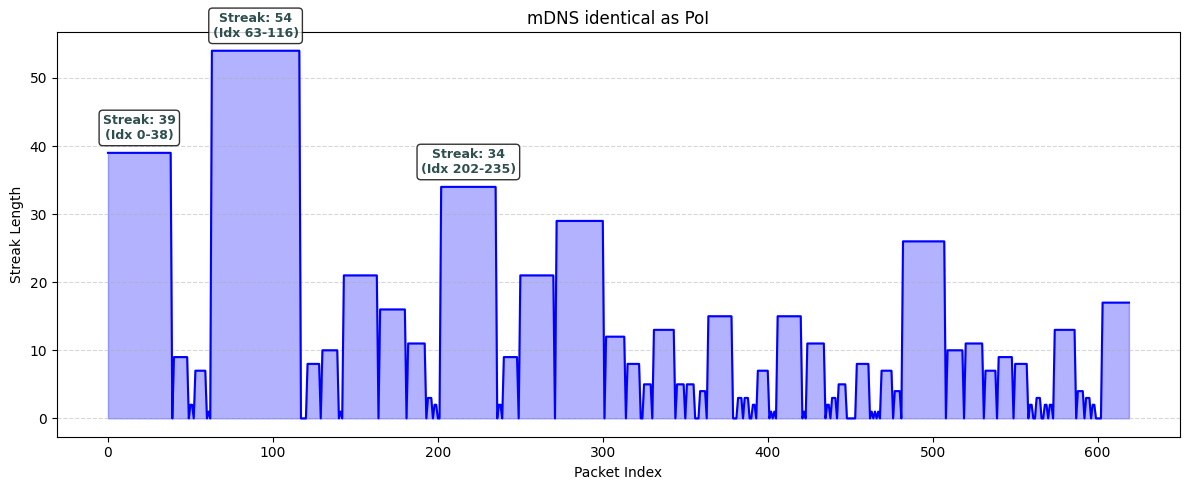

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

matches = comparison_df['is_match'].astype(int)
streak_groups = (matches != matches.shift()).cumsum()
streaks = matches.groupby(streak_groups).transform('sum') * matches
comparison_df['streak_length'] = streaks

streak_summary = comparison_df[comparison_df['is_match']].groupby(streak_groups).agg(
    start_index=('is_match', lambda x: x.index.min()),
    end_index=('is_match', lambda x: x.index.max()),
    streak_length=('streak_length', 'first')
).reset_index(drop=True)

streak_summary = streak_summary.sort_values('streak_length', ascending=False).reset_index(drop=True)

display(streak_summary.head(15))

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(comparison_df.index, comparison_df['streak_length'], color='blue', alpha=0.3)
ax.plot(comparison_df.index, comparison_df['streak_length'], color='blue', lw=1.5)

for i in range(min(3, len(streak_summary))):
    row = streak_summary.iloc[i]
    mid_point = (row['start_index'] + row['end_index']) / 2
    ax.annotate(f"Streak: {int(row['streak_length'])}\n(Idx {int(row['start_index'])}-{int(row['end_index'])})",
                xy=(mid_point, row['streak_length']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='darkslategray',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax.set_title("mDNS identical as PoI")
ax.set_xlabel("Packet Index")
ax.set_ylabel("Streak Length")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#ICD visualization growth (value)


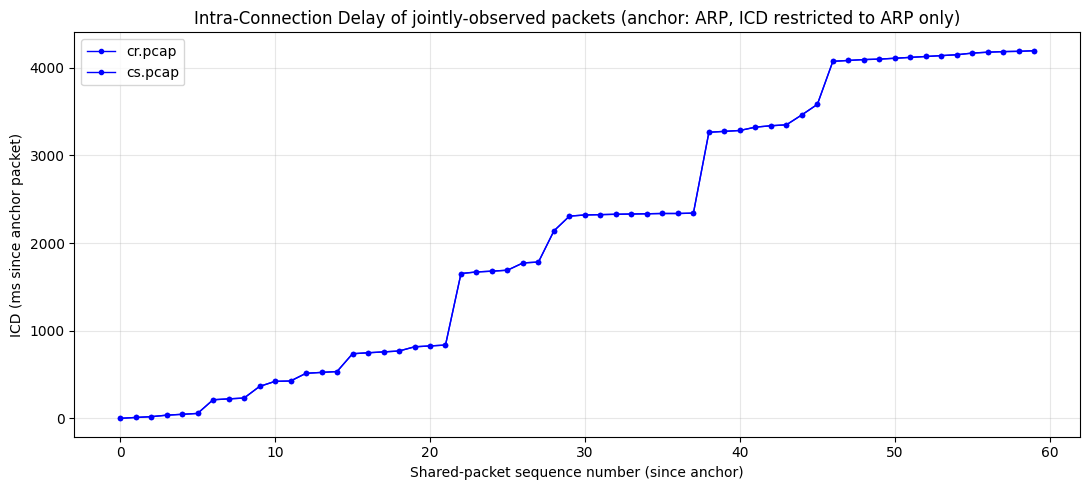

In [71]:
fig, ax = plt.subplots(figsize=(11, 5))
n_show = 60

ax.plot(range(min(n_show, len(icd_cr))), icd_cr["icd_ms"].values[:n_show],
        marker="o", ms=3, lw=1, label="cr.pcap", color="blue")
ax.plot(range(min(n_show, len(icd_cs))), icd_cs["icd_ms"].values[:n_show],
        marker="o", ms=3, lw=1, label="cs.pcap", color="blue")

ax.set_xlabel("Shared-packet sequence number (since anchor)")
ax.set_ylabel("ICD (ms since anchor packet)")
ax.set_title(f"Intra-Connection Delay of jointly-observed packets (anchor: {anchor_protocol}{', ICD restricted to ' + anchor_protocol + ' only' if RESTRICT_ICD_TO_ANCHOR_PROTOCOL else ''})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary
Quick recap of the exploratory comparison.


In [73]:

print(f"cr.pcap total packets                : {len(df_cr):,}")
print(f"cs.pcap total packets                 : {len(df_cs):,}")
print(f"Unique identical frames in both       : {len(common_hashes):,}")
print(f"Anchor / first observable protocol    : {anchor_protocol}")
print(f"Jointly-observed packets after anchor (cr): {len(icd_cr):,}")
print(f"Jointly-observed packets after anchor (cs): {len(icd_cs):,}")
print()
print("Top protocols by identical-packet count:")
print(proto_compare[proto_compare['common_unique_frames']>0]['common_unique_frames'].to_string())

cr.pcap total packets                : 55,177
cs.pcap total packets                 : 106,523
Unique identical frames in both       : 3,357
Anchor / first observable protocol    : ARP
Jointly-observed packets after anchor (cr): 772
Jointly-observed packets after anchor (cs): 768

Top protocols by identical-packet count:
protocol
UDP            1736
UDP/mDNS        620
UDP/SSDP        578
IPv6            280
UDP/DHCP         54
UDP/NBNS         43
ARP              33
UDP/NetBIOS       6
IGMP              5
UDP/LLMNR         2
